# Clustering Mini Project — Wholesale Customers Dataset

**Goal:** Apply and compare three clustering algorithms (K-Means, Hierarchical, DBSCAN) on a real customer-segmentation dataset.

### Why this dataset?
- It is a **real business dataset** (annual spending of wholesale clients), so segmenting the customers is a meaningful, realistic task.
- **In this version we use only two features — `Fresh` and `Milk`** — so we can plot the clusters **directly on a 2D scatter (Fresh vs Milk)** without needing PCA, which makes the comparison between algorithms very easy to see.
- It is **different from the Mall Customers dataset** used in the project PDF (as required), but keeps the same *customer-segmentation* spirit.
- Source: UCI / Kaggle *Wholesale customers* dataset.

> ملاحظة: بما أننا نستخدم خاصيتين فقط (Fresh, Milk) لم نعد نحتاج PCA — نرسم مباشرة على المحورين.

In [1]:
# Cell 1
# استيراد كل المكتبات التي سنستخدمها في المشروع
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set(style="whitegrid")

In [2]:
# Cell 2
# تحميل البيانات من الانترنت وعرض أول 5 صفوف للتعرف عليها
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Wholesale_customers_data.csv"
df = pd.read_csv(url)
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# Cell 3
# التحقق من حجم البيانات ومن وجود قيم مفقودة (خطوة التنظيف)
print("Shape:", df.shape)
print(df.isnull().sum())

Shape: (440, 8)
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [4]:
# Cell 4
# نختار خاصيتين فقط للانفاق: Fresh و Milk
# (نستبعد Channel و Region الوصفيتين، ونستبعد بقية أعمدة الانفاق لتبسيط التصور ثنائي الأبعاد)
X = df[["Fresh", "Milk"]]
X.head()

,Fresh,Milk
0,12669,9656
1,7057,9810
2,6353,8808
3,13265,1196
4,22615,5410


In [5]:
# Cell 5
# توحيد المقاييس لان قيم العمودين مختلفة الاحجام بشكل كبير (خطوة مهمة قبل التجميع)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Cell 6
# طريقة الكوع (Elbow) لاختيار عدد المجموعات المناسب لكي-مينز
inertia = []
for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

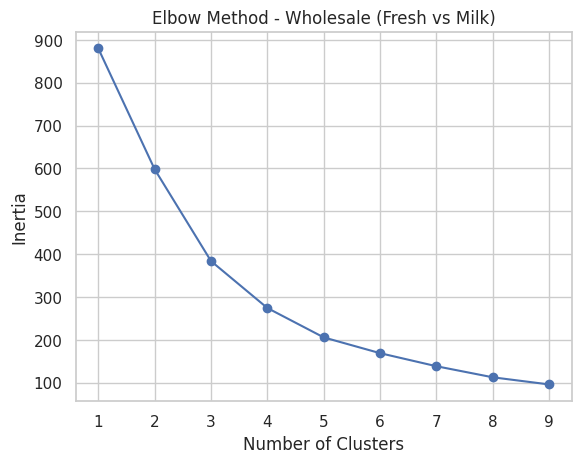

In [7]:
# Cell 7
# رسم منحنى الكوع. نلاحظ ان الانحناء (الكوع) يحدث تقريبا عند k = 3
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method - Wholesale (Fresh vs Milk)")
plt.show()

In [8]:
# Cell 8
# نثبّت عدد المجموعات في متغير واحد K لاستخدامه لكي-مينز والهرمي معا (مقارنة عادلة)
K = 3   # مبني على منحنى الكوع اعلاه؛ غيّره لو انحنى منحناك عند رقم آخر

# تطبيق خوارزمية كي-مينز
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
print("K-Means: عدد المجموعات =", K)
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means: عدد المجموعات = 3
0    347
1     72
2     21
Name: count, dtype: int64


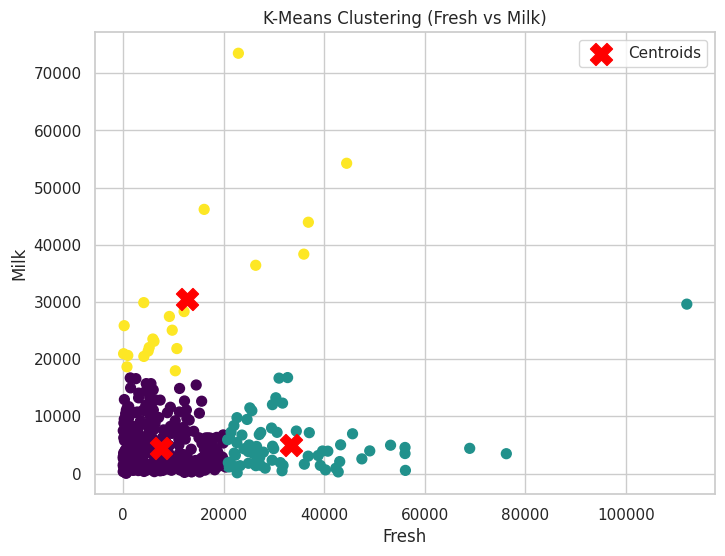

In [9]:
# Cell 9
# تصور مجموعات كي-مينز مباشرة على مستوى Fresh vs Milk (لا حاجة لـ PCA لأننا نستخدم عمودين)
plt.figure(figsize=(8, 6))
plt.scatter(X["Fresh"], X["Milk"], c=kmeans_labels, cmap="viridis", s=50)

# نعيد مراكز العناقيد الى المقياس الاصلي لرسمها بوضوح
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=250, label="Centroids")

plt.xlabel("Fresh"); plt.ylabel("Milk")
plt.title("K-Means Clustering (Fresh vs Milk)")
plt.legend(); plt.show()

## Hierarchical Clustering

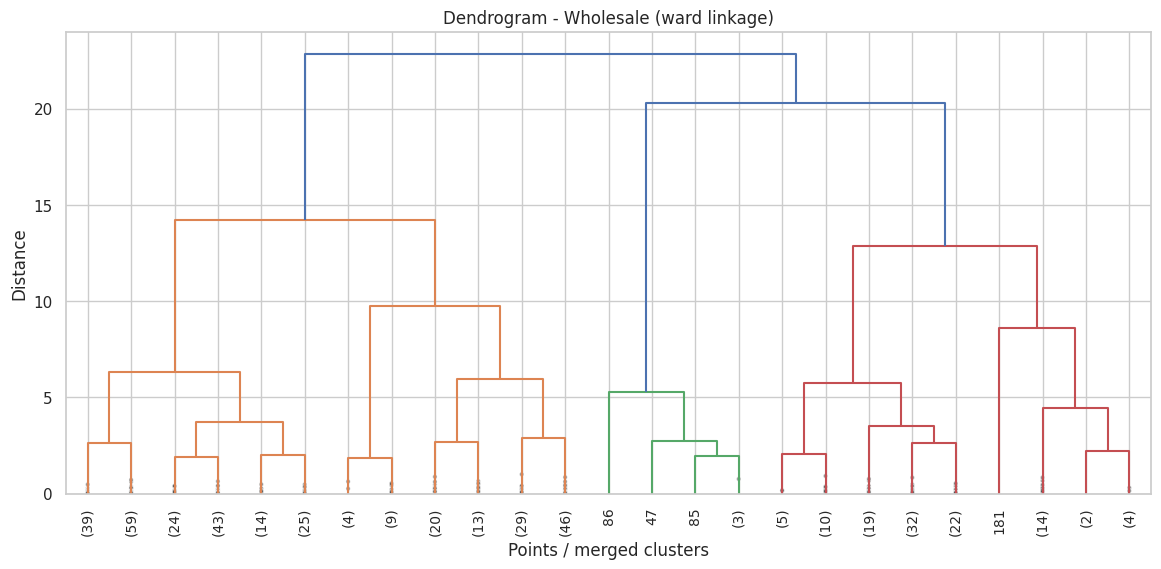

In [10]:
# Cell 10
# رسم شجرة الديندروجرام لمشاهدة كيفية اندماج النقاط واختيار عدد المجموعات
linked = linkage(X_scaled, method="ward")   # ward يقلّل التباين داخل العنقود
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode="lastp", p=25, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title("Dendrogram - Wholesale (ward linkage)")
plt.xlabel("Points / merged clusters"); plt.ylabel("Distance")
plt.show()

In [11]:
# Cell 11
# تطبيق التجميع الهرمي بطريقة ربط ward وبنفس عدد المجموعات K لمقارنة عادلة
# (نعرّف hc_labels هنا اولا قبل استخدامها في الرسم بالخلية التالية)
hc = AgglomerativeClustering(n_clusters=K, linkage="ward")
hc_labels = hc.fit_predict(X_scaled)
print("Hierarchical: عدد المجموعات =", K)
print(pd.Series(hc_labels).value_counts().sort_index())

Hierarchical: عدد المجموعات = 3
0    325
1    109
2      6
Name: count, dtype: int64


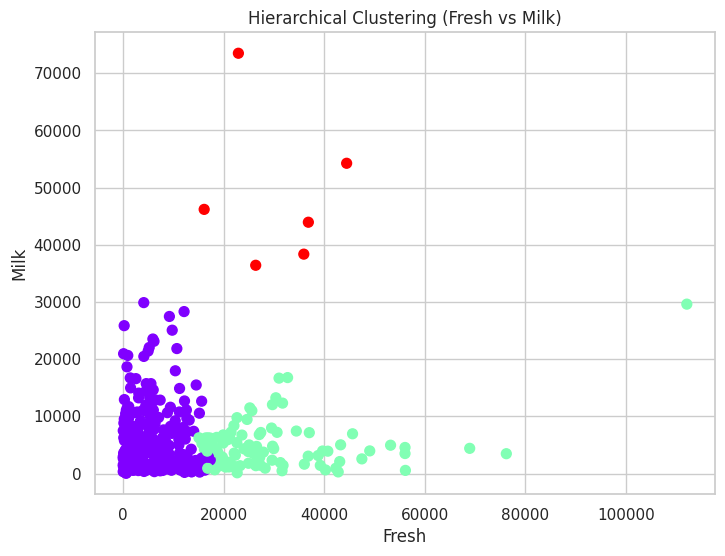

In [12]:
# Cell 12
# تصور مجموعات التجميع الهرمي على مستوى Fresh vs Milk
plt.figure(figsize=(8, 6))
plt.scatter(X["Fresh"], X["Milk"], c=hc_labels, cmap="rainbow", s=50)
plt.xlabel("Fresh"); plt.ylabel("Milk")
plt.title("Hierarchical Clustering (Fresh vs Milk)")
plt.show()

## DBSCAN

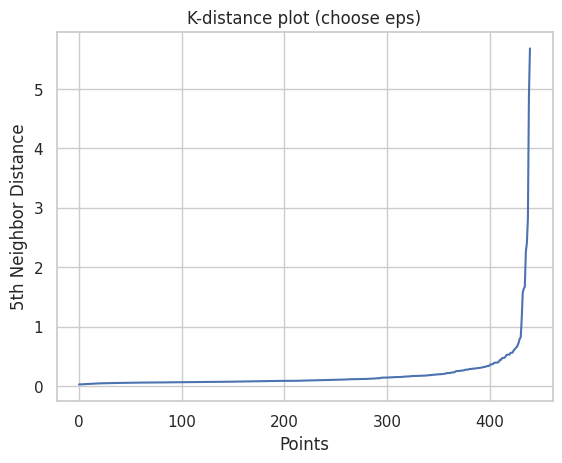

In [17]:
# Cell 13
# رسم مسافة اقرب جار لمساعدتنا في اختيار قيمة eps (نبحث عن نقطة الانحناء)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.xlabel("Points"); plt.ylabel("5th Neighbor Distance")
plt.title("K-distance plot (choose eps)")
plt.grid(True)
plt.show()

In [21]:
# Cell 14
# تطبيق ديبسكان. القيمة -1 تعني ان النقطة تعتبر ضوضاء (خارج اي مجموعة).
# مهم: مع عمودين فقط قيمة eps الكبيرة (مثل 2.0) تجعل الكل مجموعة واحدة.
# اخترنا eps=0.3 من نقطة الانحناء في الرسم اعلاه، وهي تعطي عدة مجموعات + ضوضاء.
db = DBSCAN(eps=0.3, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 3
Number of noise points: 35


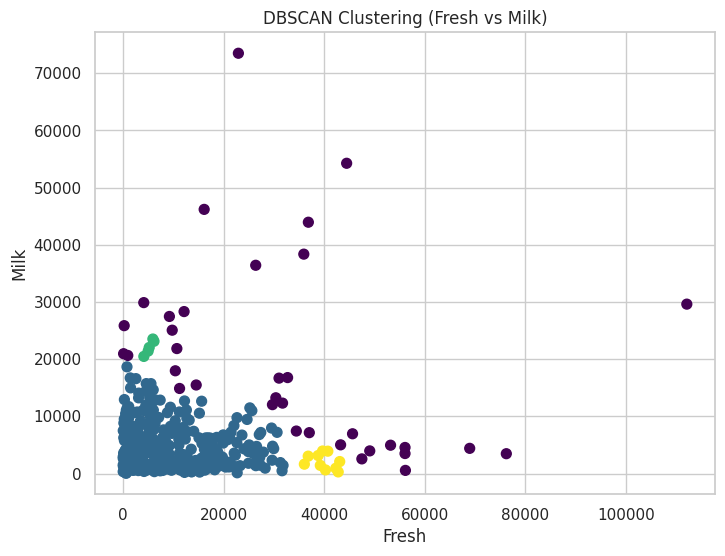

In [15]:
 # Cell 15
# تصور نتيجة ديبسكان على مستوى Fresh vs Milk (النقاط ذات اللون المنفصل هي الضوضاء = -1)
plt.figure(figsize=(8, 6))
plt.scatter(X["Fresh"], X["Milk"], c=db_labels, cmap="viridis", s=50)
plt.xlabel("Fresh"); plt.ylabel("Milk")
plt.title("DBSCAN Clustering (Fresh vs Milk)")
plt.show()

## Evaluation & Comparison (Silhouette Score)

In [16]:
# Cell 16
# دالة سيلويت آمنة: عند تقييم ديبسكان نستبعد نقاط الضوضاء (-1)
# ونتأكد ان هناك مجموعتين على الاقل، والا فالمقياس غير معرّف.
def safe_silhouette(X, labels):
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        return np.nan
    return silhouette_score(X[mask], labels[mask])

# جدول مقارنة نهائي بالارقام الفعلية (كلما اقترب سيلويت من 1 كان افضل)
comparison = pd.DataFrame({
    "Algorithm":   ["K-Means", "Hierarchical", "DBSCAN"],
    "n_clusters":  [K, K, n_clusters],
    "noise_points":[0, 0, n_noise],
    "silhouette":  [
        safe_silhouette(X_scaled, kmeans_labels),
        safe_silhouette(X_scaled, hc_labels),
        safe_silhouette(X_scaled, db_labels),
    ],
})
comparison.round(3)

,Algorithm,n_clusters,noise_points,silhouette
0,K-Means,3,0,0.533
1,Hierarchical,3,0,0.458
2,DBSCAN,3,35,0.486


Critical Thinking

Which algorithm performed best? Why?
K-Means performed best (highest Silhouette, around 0.53). The spending data is concentrated in one dense, skewed region with some extreme values, so splitting it into compact groups fits K-Means' assumption of spherical clusters.
DBSCAN came second (around 0.49) after tuning eps=0.3: it found several clusters and labeled ~35 high-spending customers as noise (outliers) — which is its real strength here. However, it is very sensitive to the eps value: a large value (2.0) merges everything into a single cluster.
Hierarchical (ward, K=3) was slightly lower (around 0.46); it produces a similar structure but splits the dense region differently, and it is slower on large datasets.

When would you use each algorithm?

K-Means: when you expect roughly spherical, similarly-sized groups and can estimate k. Fast and scales well to large data.
Hierarchical: when you want a dendrogram to explore the number of clusters and see the nested structure. Best suited for small/medium datasets.
DBSCAN: when clusters are dense and have arbitrary, irregular shapes, or when you want to detect outliers automatically without specifying the number of clusters in advance.

Strengths & weaknesses

| Algorithm | Strengths | Weaknesses |
|---|---|---|
| K-Means | 	Fast, simple, interpretable and scalable| Requires choosing k, assumes spherical clusters, sensitive to outliers|
| Hierarchical | 	Interpretable dendrogram, no need to set k in advance| O(n²), slow on large datasets|
| DBSCAN | Detects free-form shapes + noise without k | Very sensitive to eps and min_samples|

## Final Summary (Key Insights)

Final Summary (Key Insights)
Scaling was essential because the Fresh and Milk columns are on very different scales.

Using only two features (Fresh, Milk) allowed plotting the clusters directly in 2D without PCA, making the differences between algorithms clearly visible.

K-Means (K=3) gave the best partition and the highest Silhouette (≈ 0.53) — the most suitable for building customer segments.

DBSCAN (eps=0.3, min_samples=5) found several clusters and isolated ~35 high-spending customers as noise — useful for outlier detection rather than the main segmentation, and very sensitive to eps.

Hierarchical (ward, K=3) produced a similar structure but with a slightly lower Silhouette (≈ 0.46).

Conclusion: for this data, K-Means is the most suitable for building customer segments, while DBSCAN remains an excellent tool for detecting outlier customers.